This notebook aims to analyze EFO vs NLP embeddings

the main hypothesis is that NLP embeddings may capture better trait -> related-measurement similarity


In [1]:
import polars as pl
import pandas as pd 
import pickle
import os, sys
import numpy as np

from scipy.spatial.distance import cosine, pdist
from scipy.stats import percentileofscore

from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from network import knn_graph

import networkx as nx

In [2]:
# traits with at least one genetic association 
with open("../aux_data/traits_geq_oneGenAssoc.pkl","rb") as file:
    traits = pickle.load(file)

In [3]:
disease_ot = pl.read_parquet("../data/disease/disease.parquet")
disease_ot = disease_ot.filter(pl.col("id").is_in(traits))
disease_ot.head(1)

id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,narrowSynonyms,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms
str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],struct[3],struct[4]
"""DOID_0050890""","""http://purl.obolibrary.org/obo…","""synucleinopathy""","""A neurodegenerative disease th…","[""MEDGEN:1682194"", ""MESH:D000080874"", … ""UMLS:C5191670""]","[""EFO_0005772"", ""MONDO_0021179""]","[""alpha Synucleinopathies"", ""synucleinopathy""]","[""alpha synucleinopathies"", ""synucleinopathies""]",[],[],[],[],"[""EFO_0006792"", ""EFO_1001050""]","[""EFO_0005772"", ""MONDO_0021179"", … ""OTAR_0000020""]","[""EFO_0000618"", ""OTAR_0000020""]","[""EFO_0006792"", ""EFO_1001050"", … ""MONDO_0014835""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_0050890"",""DOID_0050890""}}","{[""alpha Synucleinopathies"", ""synucleinopathy""],[""alpha synucleinopathies"", ""synucleinopathies""],[],[]}"


In [4]:
efo_embeddings = pd.read_parquet("../data/efo_embeddings/embeddings.parquet")

efo_embeddings = efo_embeddings.merge(
    disease_ot.to_pandas(),
    left_on='iri',
    right_on='code',
    validate='one_to_one',
    how='inner'
)

efo_embeddings = efo_embeddings[efo_embeddings['id'].isin(traits)].reset_index(drop=True)
efo_embeddings["row_nr"] = efo_embeddings.index
efo_embeddings.head(1)

,iri,embeddings,id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,...,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms,row_nr
0,http://purl.obolibrary.org/obo/DOID_0050890,"[0.0068239146, -0.04110683, -0.0060449257, -0....",DOID_0050890,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MEDGEN:1682194, MESH:D000080874, MONDO:000051...","[EFO_0005772, MONDO_0021179]","[alpha Synucleinopathies, synucleinopathy]","[alpha synucleinopathies, synucleinopathies]",...,[],[],[],"[EFO_0006792, EFO_1001050]","[EFO_0005772, MONDO_0021179, EFO_0009386, EFO_...","[EFO_0000618, OTAR_0000020]","[EFO_0006792, EFO_1001050, MONDO_0003122, MOND...","{'isTherapeuticArea': False, 'leaf': False, 's...",{'hasExactSynonym': ['alpha Synucleinopathies'...,0


In [5]:
disease_embeddings = pl.read_parquet("../output/id_value_embeddings.parquet")
disease_embeddings.head(1)

id,variable,value,embeddings
str,str,str,"array[f32, 768]"
"""DOID_0050890""","""name""","""synucleinopathy""","[-0.982104, 0.099318, … 0.4078]"


In [6]:
disease_embeddings.shape

(62999, 4)

In [7]:
# synonyms embeddings:
embedding_map = dict(zip(disease_embeddings["value"].to_list(), disease_embeddings["embeddings"].to_list()))

In [8]:
len(embedding_map.items())

61777

In [9]:
disease_ot_synonyms = (
    disease_ot
    .explode(pl.col("exactSynonyms"))  # Explode synonyms into separate rows
    .select(['id', 'name', 'exactSynonyms'])  # Keep necessary columns
    .filter(pl.col("name") != pl.col("exactSynonyms"))  # Remove rows where name == synonym
    .unique(subset=['name', 'exactSynonyms'], keep='first', maintain_order=True)  # Remove duplicates
)

In [10]:
disease_ot_synonyms.head(1)

id,name,exactSynonyms
str,str,str
"""DOID_0050890""","""synucleinopathy""","""alpha Synucleinopathies"""


In [11]:
# add embedding-derived cosine distance between synonyms
disease_ot_synonyms = (
    disease_ot_synonyms
    .with_columns(
        pl.struct('name','exactSynonyms')
        .map_elements(
            lambda x: cosine(embedding_map[x['name']],embedding_map[x['exactSynonyms']]),
            return_dtype=pl.Float64
        ).alias('cosine_dist')
    )
)

In [12]:
# distribution of cosine distances between synonyms 
synonyms_distances = disease_ot_synonyms['cosine_dist'].to_list()
print(f"Number of synonym couples with dist: {len(synonyms_distances)}")

Number of synonym couples with dist: 44481


In [13]:
deciles = np.quantile(synonyms_distances, q=np.arange(0.1, 1., 0.1))
for i,v in enumerate(deciles):
    print(f"Decile {i}: {v:.2f}")

Decile 0: 0.02
Decile 1: 0.04
Decile 2: 0.07
Decile 3: 0.11
Decile 4: 0.15
Decile 5: 0.20
Decile 6: 0.25
Decile 7: 0.33
Decile 8: 0.44


In [14]:
rng = np.random.default_rng(42)

random_distances = pdist(
      rng.choice(disease_embeddings["embeddings"], size=450, replace=False),
      metric='cosine',
)

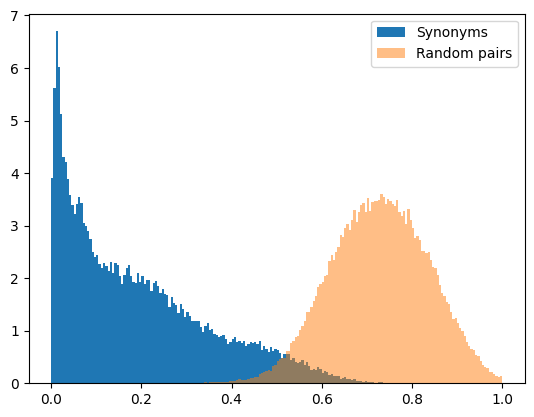

In [15]:
# Use a constant bin width to make the two histograms easier to compare visually
bin_width = 0.005
bins = np.arange(0, 1 + bin_width, bin_width)

fig, ax = plt.subplots()

# Plot the first histogram
ax.hist(
    synonyms_distances, 
    bins=bins, 
    label="Synonyms", 
    density=True
)

ax.hist(
    random_distances,
    bins=bins, 
    label="Random pairs", 
    density=True,
    alpha=0.5
)

ax.legend()

plt.show()

In [16]:
disease_ot_with_embeddings = (
    disease_ot
    .with_columns(
        pl.struct('id','name').map_elements(
            lambda t: embedding_map[t['name']],
            return_dtype=pl.Array(inner=pl.Float32, shape=768)
        ).alias("embeddings")
    )
)
disease_ot_with_embeddings = disease_ot_with_embeddings.with_row_index("row_nr")

In [17]:
disease_ot_with_embeddings.head(2)

row_nr,id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,narrowSynonyms,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms,embeddings
u32,str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],struct[3],struct[4],"array[f32, 768]"
0,"""DOID_0050890""","""http://purl.obolibrary.org/obo…","""synucleinopathy""","""A neurodegenerative disease th…","[""MEDGEN:1682194"", ""MESH:D000080874"", … ""UMLS:C5191670""]","[""EFO_0005772"", ""MONDO_0021179""]","[""alpha Synucleinopathies"", ""synucleinopathy""]","[""alpha synucleinopathies"", ""synucleinopathies""]",[],[],[],[],"[""EFO_0006792"", ""EFO_1001050""]","[""EFO_0005772"", ""MONDO_0021179"", … ""OTAR_0000020""]","[""EFO_0000618"", ""OTAR_0000020""]","[""EFO_0006792"", ""EFO_1001050"", … ""MONDO_0014835""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_0050890"",""DOID_0050890""}}","{[""alpha Synucleinopathies"", ""synucleinopathy""],[""alpha synucleinopathies"", ""synucleinopathies""],[],[]}","[-0.982104, 0.099318, … 0.4078]"
1,"""DOID_10113""","""http://purl.obolibrary.org/obo…","""trypanosomiasis""","""Infection with protozoa of the…","[""DOID:10113"", ""ICD10CM:B56"", … ""UMLS:C0041227""]","[""MONDO_0002428""]","[""Trypanosoma caused disease or disorder"", ""Trypanosoma disease or disorder"", … ""trypanosomiasis""]","[""Trypanosomiases""]",[],[],[],[],"[""MONDO_0001444"", ""EFO_0005225"", ""EFO_0008559""]","[""MONDO_0002428"", ""EFO_0001067"", ""EFO_0005741""]","[""EFO_0005741""]","[""MONDO_0001444"", ""EFO_0005225"", … ""EFO_0005529""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_10113"",""DOID_10113""}}","{[""Trypanosoma caused disease or disorder"", ""Trypanosoma disease or disorder"", … ""trypanosomiasis""],[""Trypanosomiases""],[],[]}","[-0.827013, -0.04076, … 0.280557]"


In [18]:
# calculate pairwise distances - NLP
p_distances_nlp = pairwise_distances(disease_ot_with_embeddings['embeddings'].to_list()[:], metric='cosine')

In [19]:
# calculate pairwise distances - EFO
p_distances_efo = pairwise_distances(efo_embeddings['embeddings'].to_list()[:], metric='cosine')

In [20]:
dist_distances_nlp = p_distances_nlp[np.triu_indices(p_distances_nlp.shape[0])]
dist_distances_efo = p_distances_efo[np.triu_indices(p_distances_efo.shape[0])]

In [21]:
deciles = np.quantile(dist_distances_nlp, q=np.arange(0.1, 1., 0.1))
for i,v in enumerate(deciles):
    print(f"Decile {i}: {v:.2f}")

Decile 0: 0.59
Decile 1: 0.63
Decile 2: 0.67
Decile 3: 0.69
Decile 4: 0.72
Decile 5: 0.74
Decile 6: 0.77
Decile 7: 0.80
Decile 8: 0.84


In [22]:
deciles = np.quantile(dist_distances_efo, q=np.arange(0.1, 1., 0.1))
for i,v in enumerate(deciles):
    print(f"Decile {i}: {v:.2f}")

Decile 0: 0.12
Decile 1: 0.15
Decile 2: 0.18
Decile 3: 0.20
Decile 4: 0.22
Decile 5: 0.25
Decile 6: 0.28
Decile 7: 0.32
Decile 8: 0.38


In [23]:
efo_embeddings.head(1)

,iri,embeddings,id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,...,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms,row_nr
0,http://purl.obolibrary.org/obo/DOID_0050890,"[0.0068239146, -0.04110683, -0.0060449257, -0....",DOID_0050890,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MEDGEN:1682194, MESH:D000080874, MONDO:000051...","[EFO_0005772, MONDO_0021179]","[alpha Synucleinopathies, synucleinopathy]","[alpha synucleinopathies, synucleinopathies]",...,[],[],[],"[EFO_0006792, EFO_1001050]","[EFO_0005772, MONDO_0021179, EFO_0009386, EFO_...","[EFO_0000618, OTAR_0000020]","[EFO_0006792, EFO_1001050, MONDO_0003122, MOND...","{'isTherapeuticArea': False, 'leaf': False, 's...",{'hasExactSynonym': ['alpha Synucleinopathies'...,0


In [24]:
def compare_embedding_distances(trait1, trait2):

    # dist_distances_nlp
    # dist_distances_efo
    
    row1_nlp = disease_ot_with_embeddings.filter(pl.col("name") == trait1)
    row2_nlp = disease_ot_with_embeddings.filter(pl.col("name") == trait2)

    row1_nlp_idx = row1_nlp['row_nr'].to_list()[0]
    row2_nlp_idx = row2_nlp['row_nr'].to_list()[0]

    row1_nlp_iri = row1_nlp['code'].to_list()[0]
    row2_nlp_iri = row2_nlp['code'].to_list()[0]
    
    row1_efo = efo_embeddings[efo_embeddings['iri']==row1_nlp_iri]
    row2_efo = efo_embeddings[efo_embeddings['iri']==row2_nlp_iri]

    emb1 = row1_efo['embeddings'].to_list()[0]
    emb2 = row2_efo['embeddings'].to_list()[0]
    
    row1_efo_idx = row1_efo['row_nr'].to_list()[0]
    row2_efo_idx = row2_efo['row_nr'].to_list()[0]

    nlp_cosine = p_distances_nlp[row1_nlp_idx,row2_nlp_idx]
    efo_cosine = p_distances_efo[row1_efo_idx,row2_efo_idx]

    percentile_nlp = percentileofscore(dist_distances_nlp, nlp_cosine)
    percentile_efo = percentileofscore(dist_distances_efo, efo_cosine)

    print(f"NLP: {nlp_cosine}")
    print(f"EFO: {efo_cosine}")

    print(f"NLP perc: {percentile_nlp}")
    print(f"EFO perc: {percentile_efo}")




In [25]:
compare_embedding_distances('obesity','body mass index')

NLP: 0.26122258213103056
EFO: 0.3396183252334595
NLP perc: 0.09223967974650998
EFO perc: 83.8086892319912


In [26]:
compare_embedding_distances('glucose measurement','type 2 diabetes mellitus')

NLP: 0.5380454941644506
EFO: 0.5425523519515991
NLP perc: 4.332618381190909
EFO perc: 98.68942858830309


In [27]:
compare_embedding_distances('anemia','hemoglobin measurement')

NLP: 0.42916157863656346
EFO: 0.47645705938339233
NLP perc: 0.5953381663097388
EFO perc: 96.8367218283408


In [28]:
compare_embedding_distances('Hypercholesterolemia','free cholesterol in large LDL measurement')

NLP: 0.49003928490009163
EFO: 0.15312618017196655
NLP perc: 1.7474958114638
EFO perc: 20.47444394699329


In [29]:
compare_embedding_distances("Crohn's disease",'ulcerative colitis')

NLP: 0.21779197885897927
EFO: 0.02216935157775879
NLP perc: 0.06155046794574463
EFO perc: 1.2103328363467951


In [30]:
compare_embedding_distances("Alzheimer disease",'beta-amyloid 1-42 measurement')

NLP: 0.4354289597820351
EFO: 0.33785849809646606
NLP perc: 0.6588563549923574
EFO perc: 83.5021829015554


In [31]:
compare_embedding_distances("kidney disease",'serum creatinine amount')

NLP: 0.7520771898856389
EFO: 0.2928367257118225
NLP perc: 64.13946530402414
EFO perc: 73.86031396599824


In [32]:
compare_embedding_distances("Parkinson disease",'kidney disease')

NLP: 0.6932049377361282
EFO: 0.49523383378982544
NLP perc: 40.30342242098573
EFO perc: 97.52433291686356


In [33]:
compare_embedding_distances("multiple sclerosis",'multiple sclerosis symptom measurement')

NLP: 0.2847963746020299
EFO: 0.2769191861152649
NLP perc: 0.11234204076586654
EFO perc: 69.46601972861072


In [34]:
compare_embedding_distances("hypertension",'Elevated systolic blood pressure')

NLP: 0.30030213350396406
EFO: 0.2992023229598999
NLP perc: 0.12823019015373188
EFO perc: 75.45592815558823


In [35]:
compare_embedding_distances("Iron deficiency anemia",'ferritin measurement')

NLP: 0.5276077608645312
EFO: 0.13589215278625488
NLP perc: 3.5639948185842254
EFO perc: 14.46797698088665


In [36]:
compare_embedding_distances("Alzheimer disease",'t-tau measurement')

NLP: 0.5970390237264631
EFO: 0.33666276931762695
NLP perc: 11.999925630187207
EFO perc: 83.29134139131888


In [37]:
compare_embedding_distances("neuropathy","peripheral neuropathy")

NLP: 0.07946422745518666
EFO: 0.22445207834243774
NLP perc: 0.013961252732669259
EFO perc: 50.46818718991522


In [38]:
# filter efo embeddings for traits 
compare_embedding_distances("neuropathy","Chronic pain")

NLP: 0.4883876941017149
EFO: 0.34122931957244873
NLP perc: 1.693880961795069
EFO perc: 84.08589087019628


In [39]:
# 5th percentile of NLP
def get_similar_at_threshold(name, percentile=0.05):

    fifth_perc = np.quantile(dist_distances_nlp, q=percentile)
    # ('glucose measurement','type 2 diabetes mellitus')
    # take all the elements at 5fth perc distance from name
    row1_nlp = disease_ot_with_embeddings.filter(pl.col("name") == name)
    row1_nlp_idx = row1_nlp['row_nr'].to_list()[0]
    nlp_cosine = p_distances_nlp[row1_nlp_idx,:]
    similars = np.where(nlp_cosine <= fifth_perc)[0]

    for s in similars:
        str_similar = disease_ot_with_embeddings[int(s)]['name'].to_list()[0]
        print(f"{str_similar}")


In [40]:
disease_ot_with_embeddings.height

18518

In [41]:
get_similar_at_threshold(name='glucose measurement', percentile=0.005)
    

Glucose intolerance
Glycosuria
Abnormal glucose homeostasis
Abnormal blood glucose concentration
glucose homeostasis trait
level of Glu-Glu in blood
blood glucose amount
glucose tolerance test
insulin measurement
glucose measurement
glycoprotein measurement
carbohydrate measurement
diabetes mellitus biomarker
hexose measurement
1,5 anhydroglucitol measurement
glucose-dependent insulinotropic peptide measurement
sugar consumption measurement
glucuronate measurement
glucose change measurement
glycerate measurement
glucose-to-mannose ratio
Maltose measurement
xylose measurement
methyl glucopyranoside (alpha + beta) measurement
ethyl beta-glucopyranoside measurement
gluconate measurement
glucokinase measurement


In [42]:
get_similar_at_threshold(name='neuropathy', percentile=0.01)

Nephropathy
Abnormality of the nervous system
Sensory neuropathy
Neurodegeneration
Paraparesis
EMG: neuropathic changes
Paralysis
Motor axonal neuropathy
Sensorimotor neuropathy
Impaired pain sensation
Motor neuron atrophy
Peripheral demyelination
Abnormal central motor function
Abnormal nervous system physiology
autoimmune disorder of peripheral nervous system
nervous system benign neoplasm
autoimmune neuropathy
autonomic neuropathy
diabetic polyneuropathy
neuritis
optic nerve disorder
motor peripheral neuropathy
congenital nervous system disorder
sensory peripheral neuropathy
demyelinating disease
radiculopathy
autoimmune disorder of the nervous system
demyelinating polyneuropathy
cranial nerve neuropathy
axonal neuropathy
hereditary motor and sensory neuropathy
Charcot-Marie-Tooth disease
acquired peripheral neuropathy
neuralgic amyotrophy
paraneoplastic neurologic syndrome
infectious disorder of the nervous system
neuromuscular junction disease
hereditary peripheral neuropathy
peri

In [43]:

thresh_2_5_perc = np.quantile(dist_distances_nlp, q=0.025)
thresh_1_perc = np.quantile(dist_distances_nlp, q=0.01)
thresh_0_5_perc = np.quantile(dist_distances_nlp, q=0.005)
thresh_0_25_perc = np.quantile(dist_distances_nlp, q=0.0025)

print(f"Threshold at 2.5%: {thresh_2_5_perc}")
print(f"Threshold at 1%: {thresh_1_perc}")
print(f"Threshold at 0.5%: {thresh_0_5_perc}")
print(f"Threshold at 0.25%: {thresh_0_25_perc}")


Threshold at 2.5%: 0.50891793824649
Threshold at 1%: 0.4597308840299726
Threshold at 0.5%: 0.41796000422281
Threshold at 0.25%: 0.36639322037844346


In [44]:
def create_network(threhsold):
    G = nx.from_numpy_array(
        p_distances_nlp < threhsold, 
        nodelist=disease_ot_with_embeddings['id'].to_list()
    )
    G.remove_edges_from(nx.selfloop_edges(G))
    return(list(G.edges()))


In [45]:
G_thresh_2_5_perc = create_network(thresh_2_5_perc)
G_thresh_1_perc = create_network(thresh_1_perc)
G_thresh_0_5_perc = create_network(thresh_0_5_perc)
G_thresh_0_25_perc = create_network(thresh_0_25_perc)

In [46]:
with open("../output/trait_trait_edges_2_5.pkl","wb") as file:
    pickle.dump(G_thresh_2_5_perc, file)
with open("../output/trait_trait_edges_1.pkl","wb") as file:
    pickle.dump(G_thresh_1_perc, file)
with open("../output/trait_trait_edges_0_5.pkl","wb") as file:
    pickle.dump(G_thresh_0_5_perc, file)
with open("../output/trait_trait_edges_0_25.pkl","wb") as file:
    pickle.dump(G_thresh_0_25_perc, file)